In [4]:
print('Hello World')

Hello World


In [1]:
import pandas as pd

data = {
    "text": [
        "I love machine learning",
        "Machine learning is amazing",
        "I hate slow computers",
        "Deep learning uses neural networks",
        "Computers can learn patterns"
    ]
}

df = pd.DataFrame(data)

print(df)

                                 text
0             I love machine learning
1         Machine learning is amazing
2               I hate slow computers
3  Deep learning uses neural networks
4        Computers can learn patterns


In [3]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()

bow_matrix = vectorizer.fit_transform(df["text"])

print('Vocabulary')
print(vectorizer.get_feature_names_out())

print("bow matrix")
print(bow_matrix.toarray())

Vocabulary
['amazing' 'can' 'computers' 'deep' 'hate' 'is' 'learn' 'learning' 'love'
 'machine' 'networks' 'neural' 'patterns' 'slow' 'uses']
bow matrix
[[0 0 0 0 0 0 0 1 1 1 0 0 0 0 0]
 [1 0 0 0 0 1 0 1 0 1 0 0 0 0 0]
 [0 0 1 0 1 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 1 0 0 0 1 0 0 1 1 0 0 1]
 [0 1 1 0 0 0 1 0 0 0 0 0 1 0 0]]


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(df["text"])

print("Vocabulary")
print(tfidf.get_feature_names_out())

print("TF-IDF Matrix:")
print(tfidf_matrix.toarray())

Vocabulary
['amazing' 'can' 'computers' 'deep' 'hate' 'is' 'learn' 'learning' 'love'
 'machine' 'networks' 'neural' 'patterns' 'slow' 'uses']
TF-IDF Matrix:
[[0.         0.         0.         0.         0.         0.
  0.         0.4622077  0.69015927 0.55681615 0.         0.
  0.         0.         0.        ]
 [0.56801408 0.         0.         0.         0.         0.56801408
  0.         0.38040565 0.         0.45827018 0.         0.
  0.         0.         0.        ]
 [0.         0.         0.49552379 0.         0.61418897 0.
  0.         0.         0.         0.         0.         0.
  0.         0.61418897 0.        ]
 [0.         0.         0.         0.47412465 0.         0.
  0.         0.3175268  0.         0.         0.47412465 0.47412465
  0.         0.         0.47412465]
 [0.         0.52335825 0.42224214 0.         0.         0.
  0.52335825 0.         0.         0.         0.         0.
  0.52335825 0.         0.        ]]


In [1]:
from gensim.models import Word2Vec

sentences = [
    ["i", "love", "machine", "learning"],
    ["machine", "learning", "is", "amazing"],
    ["deep", "learning", "uses", "neural", "networks"]
]

model = Word2Vec(
    sentences,
    vector_size=5,
    window=2,
    min_count=1
)

print(model.wv["learning"])

[-0.01072454  0.00472863  0.10206699  0.18018547 -0.186059  ]


In [7]:
import math
import re
from collections import Counter

In [8]:
documents = [
    "I love machine learning",
    "Machine learning is fun",
    "I love deep learning",
    "Pizza and burger are tasty",
]

for number, document in enumerate(documents, start=1):
    print(f"Document {number}: {document}")

Document 1: I love machine learning
Document 2: Machine learning is fun
Document 3: I love deep learning
Document 4: Pizza and burger are tasty


In [9]:
tokenized_documents = []

for document in documents:
    tokens = re.findall(r"[a-z]+", document.lower())
    tokenized_documents.append(tokens)

for number, tokens in enumerate(tokenized_documents, start=1):
    print(f"Document {number}: {tokens}")

Document 1: ['i', 'love', 'machine', 'learning']
Document 2: ['machine', 'learning', 'is', 'fun']
Document 3: ['i', 'love', 'deep', 'learning']
Document 4: ['pizza', 'and', 'burger', 'are', 'tasty']


In [10]:
all_words = []

for tokens in tokenized_documents:
    for word in tokens:
        all_words.append(word)

vocabulary = sorted(set(all_words))

print("Vocabulary size:", len(vocabulary))
print(vocabulary)

Vocabulary size: 12
['and', 'are', 'burger', 'deep', 'fun', 'i', 'is', 'learning', 'love', 'machine', 'pizza', 'tasty']


In [11]:
bow_matrix = []

for tokens in tokenized_documents:
    word_counts = Counter(tokens)
    document_vector = []

    for word in vocabulary:
        document_vector.append(word_counts[word])

    bow_matrix.append(document_vector)

print("Vocabulary columns:")
print(vocabulary)

Vocabulary columns:
['and', 'are', 'burger', 'deep', 'fun', 'i', 'is', 'learning', 'love', 'machine', 'pizza', 'tasty']


In [12]:
print("Bag of Words matrix:")
for number, vector in enumerate(bow_matrix, start=1):
    print(f"Doc {number}:", vector)

Bag of Words matrix:
Doc 1: [0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0]
Doc 2: [0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0]
Doc 3: [0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0]
Doc 4: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1]


In [13]:
tf_matrix = []

for tokens in tokenized_documents:
    word_counts = Counter(tokens)
    total_words = len(tokens)
    document_tf = []

    for word in vocabulary:
        tf_value = word_counts[word] / total_words
        document_tf.append(tf_value)

    tf_matrix.append(document_tf)

print("TF matrix:")
for number, vector in enumerate(tf_matrix, start=1):
    rounded_vector = [round(value, 3) for value in vector]
    print(f"Doc {number}:", rounded_vector)

TF matrix:
Doc 1: [0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.0, 0.25, 0.25, 0.25, 0.0, 0.0]
Doc 2: [0.0, 0.0, 0.0, 0.0, 0.25, 0.0, 0.25, 0.25, 0.0, 0.25, 0.0, 0.0]
Doc 3: [0.0, 0.0, 0.0, 0.25, 0.0, 0.25, 0.0, 0.25, 0.25, 0.0, 0.0, 0.0]
Doc 4: [0.2, 0.2, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.2]


In [14]:
total_documents = len(tokenized_documents)
idf_vector = []

for word in vocabulary:
    documents_with_word = 0

    for tokens in tokenized_documents:
        if word in tokens:
            documents_with_word += 1

    idf_value = math.log10(total_documents / documents_with_word)
    idf_vector.append(idf_value)

print("IDF values:")
for word, idf_value in zip(vocabulary, idf_vector):
    print(f"{word:>10}: {idf_value:.3f}")

IDF values:
       and: 0.602
       are: 0.602
    burger: 0.602
      deep: 0.602
       fun: 0.602
         i: 0.301
        is: 0.602
  learning: 0.125
      love: 0.301
   machine: 0.301
     pizza: 0.602
     tasty: 0.602


In [15]:
tfidf_matrix = []

for tf_vector in tf_matrix:
    tfidf_vector = []

    for tf_value, idf_value in zip(tf_vector, idf_vector):
        tfidf_vector.append(tf_value * idf_value)

    tfidf_matrix.append(tfidf_vector)

print("Vocabulary columns:")
print(vocabulary)

Vocabulary columns:
['and', 'are', 'burger', 'deep', 'fun', 'i', 'is', 'learning', 'love', 'machine', 'pizza', 'tasty']


In [17]:
for number, vector in enumerate(tfidf_matrix, start=1):
    rounded_vector = [round(value, 3) for value in vector]
    print(f"Doc {number}:", rounded_vector)

Doc 1: [0.0, 0.0, 0.0, 0.0, 0.0, 0.075, 0.0, 0.031, 0.075, 0.075, 0.0, 0.0]
Doc 2: [0.0, 0.0, 0.0, 0.0, 0.151, 0.0, 0.151, 0.031, 0.0, 0.075, 0.0, 0.0]
Doc 3: [0.0, 0.0, 0.0, 0.151, 0.0, 0.075, 0.0, 0.031, 0.075, 0.0, 0.0, 0.0]
Doc 4: [0.12, 0.12, 0.12, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.12, 0.12]


In [18]:
for document_number, tfidf_vector in enumerate(tfidf_matrix, start=1):
    word_scores = []

    for word, score in zip(vocabulary, tfidf_vector):
        word_scores.append((word, score))

    word_scores.sort(key=lambda item: item[1], reverse=True)

    print(f"Document {document_number} top words:")
    for word, score in word_scores[:3]:
        print(f"  {word:>10} -> {score:.3f}")

Document 1 top words:
           i -> 0.075
        love -> 0.075
     machine -> 0.075
Document 2 top words:
         fun -> 0.151
          is -> 0.151
     machine -> 0.075
Document 3 top words:
        deep -> 0.151
           i -> 0.075
        love -> 0.075
Document 4 top words:
         and -> 0.120
         are -> 0.120
      burger -> 0.120


In [1]:
from gensim.models import Word2Vec

sentences = [
    ["i", "love", "machine", "learning"],
    ["nlp", "is", "fun"],
    ["i", "love", "nlp"]
]

model = Word2Vec(
    sentences,
    vector_size=50,
    window=2,
    min_count=1,
    sg=0
)

print(model.wv["nlp"])

[-1.0724545e-03  4.7286271e-04  1.0206699e-02  1.8018546e-02
 -1.8605899e-02 -1.4233618e-02  1.2917745e-02  1.7945977e-02
 -1.0030856e-02 -7.5267432e-03  1.4761009e-02 -3.0669428e-03
 -9.0732267e-03  1.3108104e-02 -9.7203208e-03 -3.6320353e-03
  5.7531595e-03  1.9837476e-03 -1.6570430e-02 -1.8897636e-02
  1.4623532e-02  1.0140524e-02  1.3515387e-02  1.5257311e-03
  1.2701781e-02 -6.8107317e-03 -1.8928028e-03  1.1537147e-02
 -1.5043275e-02 -7.8722071e-03 -1.5023164e-02 -1.8600845e-03
  1.9076237e-02 -1.4638334e-02 -4.6675373e-03 -3.8754821e-03
  1.6154874e-02 -1.1861792e-02  9.0324880e-05 -9.5074680e-03
 -1.9207101e-02  1.0014586e-02 -1.7519170e-02 -8.7836506e-03
 -7.0199967e-05 -5.9236289e-04 -1.5322480e-02  1.9229487e-02
  9.9641159e-03  1.8466286e-02]


In [2]:
from gensim.models import Word2Vec

sentences = [
    ["i", "love", "machine", "learning"],
    ["nlp", "is", "fun"],
    ["i", "love", "nlp"]
]

model = Word2Vec(
    sentences,
    vector_size=50,
    window=2,
    min_count=1,
    sg=1
)

print(model.wv.most_similar("nlp"))

[('i', 0.1267007291316986), ('love', 0.04237300157546997), ('learning', 0.012442178092896938), ('fun', -0.01447527389973402), ('machine', -0.059746481478214264), ('is', -0.11821284145116806)]


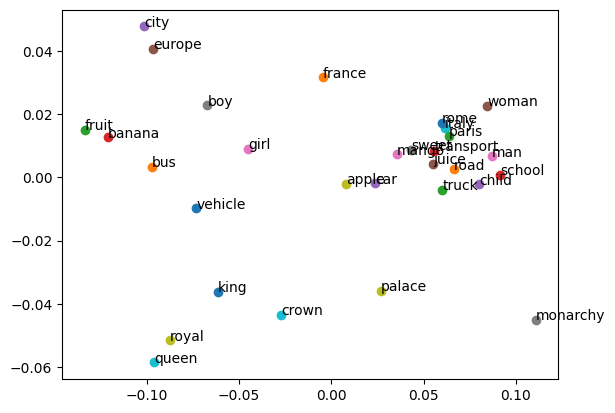

In [17]:
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

sentences = [
    ["king", "queen", "royal", "crown", "palace"],
    ["queen", "king", "monarchy", "royal"],
    ["man", "woman", "boy", "girl"],
    ["boy", "girl", "child", "school"],
    ["paris", "france", "europe", "city"],
    ["rome", "italy", "europe", "city"],
    ["apple", "banana", "fruit", "sweet"],
    ["mango", "banana", "fruit", "juice"],
    ["car", "bus", "vehicle", "transport"],
    ["truck", "bus", "road", "vehicle"]
]

model = Word2Vec(
    sentences,
    vector_size=100,
    window=3,
    min_count=1,
    sg=1,
    epochs=1000
)

words = list(model.wv.index_to_key)
vectors = [model.wv[word] for word in words]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

for i, word in enumerate(words):
    plt.scatter(result[i, 0], result[i, 1])
    plt.text(result[i, 0], result[i, 1], word)

plt.show()

In [8]:
import fasttext

model = fasttext.train_unsupervised(
    "/Users/santhoshkumarv/vs_code_projects/internship-harshith/Week6/day3/sample.txt",
    model='skipgram',
    epoch=10,
    lr=0.05
)

print(model.get_word_vector("playing"))

Read 0M words
Number of words:  1
Number of labels: 0


[-9.7013375e-04  7.9528865e-05  1.7745452e-03 -1.5961491e-03
  2.7779588e-03 -2.7132913e-04 -1.6125391e-03  9.7372147e-05
  7.3880347e-04 -3.8625250e-05  6.9550466e-04  2.2794795e-03
 -2.0900981e-03  1.1427352e-03  3.9681006e-04  7.2576513e-04
  1.4247514e-03 -7.3499337e-04  2.4635459e-03  1.1086160e-03
  1.6676746e-03 -6.6845643e-04 -6.5131159e-04 -1.7635904e-03
 -1.5100701e-03 -1.2218818e-04 -1.4099982e-03 -2.0017430e-06
 -1.1196828e-03  2.5863465e-06 -1.8882201e-04  1.4456655e-03
 -6.3808402e-04  8.4940424e-05  2.0166527e-04 -5.6538894e-04
 -1.3821195e-04 -1.7530447e-03  1.9622338e-03 -2.8272234e-03
  6.6534296e-04 -1.1804379e-03 -5.3160329e-04  8.3125418e-04
 -4.2050433e-06 -4.3952026e-04  3.2922096e-04 -3.2428561e-03
 -7.6066976e-04  1.6310806e-03  2.3893651e-03 -1.1345854e-03
 -1.1853576e-03 -1.1663771e-04 -1.9650883e-04 -9.1427151e-04
 -1.2094651e-03  1.6551996e-03 -4.8064091e-04 -5.3641811e-04
  1.6093763e-04 -1.6692765e-03 -1.5017083e-03  2.3417019e-03
  8.8048680e-04  7.90405

Progress: 100.0% words/sec/thread:     887 lr:  0.000000 avg.loss:       nan ETA:   0h 0m 0s


In [13]:
import fasttext

model = fasttext.train_unsupervised(
    "sample.txt",
    model="skipgram",
    epoch=10
)

print(model.get_word_vector("machine"))

Read 0M words
Number of words:  57
Number of labels: 0


[ 0.01221026  0.10343586 -0.22033909  0.00380827  0.6019204  -0.46132416
  0.5541073  -0.22203551  0.13902129  0.18797322  0.02857298  0.11542256
  0.05889017 -0.05192553 -0.19609396  0.22838034  0.08069286  0.4814441
 -0.03719735 -0.25026584 -0.24856412  0.32154924 -0.2078824  -0.24235363
  0.3048951  -0.15364435  0.0357425  -0.20829448  0.06148234  0.08130182
 -0.2544615  -0.03928681 -0.41690484 -0.21706894 -0.55227554  0.07914085
 -0.06315445 -0.21644533 -0.3582014  -0.0740048  -0.07654624  0.49987137
  0.11926426  0.02187052 -0.20797224  0.00995802 -0.07163177 -0.29821414
  0.03823707  0.1286903  -0.45007545  0.4007728   0.03070406 -0.05855983
 -0.22005759 -0.28309572  0.01100823  0.33388013  0.6823044   0.1813169
 -0.14069502 -0.00352398  0.5122804   0.24932085 -0.09256514 -0.09252558
  0.09580095  0.24385469  0.01017598  0.29296967 -0.5110731  -0.08704571
 -0.15278298 -0.22459134 -0.01467649 -0.07469824  0.13830131  0.09479863
  0.1801209  -0.10333594  0.14987202 -0.01689421  0.2

Progress: 100.0% words/sec/thread:  807368 lr:  0.000000 avg.loss:  2.153432 ETA:   0h 0m 0s


In [14]:
print(model.get_nearest_neighbors("machine"))

[(0.9982883334159851, 'projects.'), (0.9977990984916687, 'for'), (0.9973030686378479, 'popular'), (0.9971734285354614, 'Python'), (0.9965466856956482, 'Machine'), (0.9558461308479309, 'transforming'), (0.9267560839653015, 'technology.'), (0.868398904800415, 'learning'), (0.8444386720657349, 'is'), (0.712766170501709, '</s>')]


In [1]:
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained(
    'bert-base-uncased'
)

model = BertModel.from_pretrained(
    'bert-base-uncased'
)

text = "I love natural language processing"

inputs = tokenizer(
    text,
    return_tensors="pt"
)

outputs = model(**inputs)

embeddings = outputs.last_hidden_state

print(embeddings.shape)

/Users/santhoshkumarv/vs_code_projects/internship-harshith/Week6/day3/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 19798.53it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

N

torch.Size([1, 7, 768])
